In [1]:
!pip install tensorflow pandas numpy matplotlib seaborn scikit-learn nltk

In [2]:
import pandas as pd

df = pd.read_csv("customer_support_text_classification.csv")

print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  

Dataset Shape:
(1500, 6)

Columns:
Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')


sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


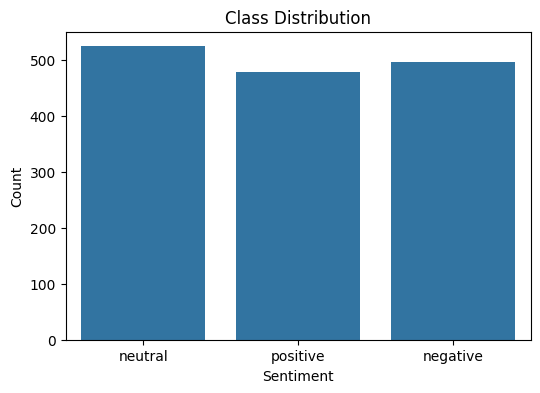


Average Text Length:
72.75666666666666


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class distribution
print(df['sentiment_label'].value_counts())

# Plot distribution
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment_label', data=df)

plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# Average text length
df['text_length'] = df['customer_message'].apply(len)

print("\nAverage Text Length:")
print(df['text_length'].mean())

In [4]:
import re
import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['cleaned_text'] = df['customer_message'].apply(clean_text)

print(df[['customer_message', 'cleaned_text']].head())

                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                        cleaned_text  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Features and target
X = df['cleaned_text']
y = df['sentiment_label']

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)

X_vectorized = vectorizer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression model
model = LogisticRegression()

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



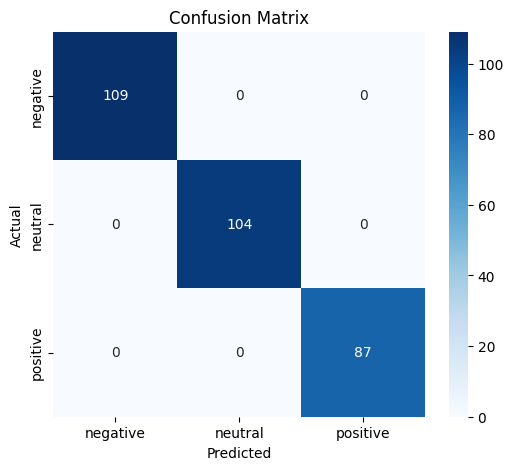

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("model_evaluation.png")

plt.show()

In [7]:
sample_df = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

print(sample_df)

sample_df.to_csv("sample_predictions.txt", index=False)

     Actual Predicted
0   neutral   neutral
1  positive  positive
2   neutral   neutral
3  negative  negative
4  negative  negative
5  negative  negative
6  negative  negative
7   neutral   neutral
8  negative  negative
9  negative  negative


# LSTM Sequence Model Architecture

1. Input Sequence
Text sentences are converted into token sequences.

2. Embedding Layer
The embedding layer converts tokens into dense vector representations.

3. LSTM Layer
The LSTM layer processes sequential information and captures long-term dependencies.

4. Dense Output Layer
The dense layer predicts the sentiment category.

5. Loss Function
Sparse categorical crossentropy

6. Evaluation Metric
Accuracy